# Get the modules

In [4]:
# Notebook cell mein run karo
import sys
print(sys.executable)



c:\Users\Neel\Desktop\Azure_open_ai\myenv\Scripts\python.exe


In [5]:
import langchain, os, dotenv, pandas as pd, langchain_core, langchain_community,  matplotlib.pyplot as plt
import langchain_text_splitters, langchain_docling, langchain_chroma, langchain_openai, os
import seaborn as sns, numpy as np
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_core.documents import Document
from langchain_community.document_loaders import PyMuPDFLoader, PyPDFLoader, ToMarkdownLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter,CharacterTextSplitter, MarkdownHeaderTextSplitter
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import FAISS
from langchain_core.vectorstores import VectorStoreRetriever
from langchain_classic.retrievers import MultiQueryRetriever, ContextualCompressionRetriever
import pymupdf4llm, tempfile


import warnings
warnings.filterwarnings("ignore")
import tiktoken

dotenv.load_dotenv()

c:\Users\Neel\Desktop\Azure_open_ai\myenv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
c:\Users\Neel\Desktop\Azure_open_ai\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

# Get the path

In [6]:
api_key = os.getenv("OPENAI_API_KEY")

In [7]:

# Pdf path 
pdf_path= r"C:\Users\Neel\Desktop\Azure_open_ai\Loader\pdfs\Practical Statistics for Data Scientists.pdf"



# Loader Function

In [8]:

class MyRetriver():
  """This class defines a retriever that loads documents from a PDF file and returns a list of documents based on the specified page range."""


  def __init__(self, 
               pdf_path, 
               first_page=0, 
               last_page=100, 
               vectorestore_type="chroma", 
               collection_name=None, 
               persist_directory=None,
               k=1, 
               mmr_tempareture=0.5,
               chunk_size=500,
               chunk_overlap=50,
               retriver_type = None,
               spliter_type="recursive_text_splitter",
               data_load_type="normal"
                ):
    
    """Initializes the retriever with the PDF path and page range."""

    #
    self.__pdf_path = pdf_path
    self.first_page = first_page
    self.last_page = last_page
    self.vectorestore_type = vectorestore_type
    self.__collection_name = collection_name
    self.__persist_directory = persist_directory
    self.k = k
    self.mmr_tempareture = mmr_tempareture
    self.chunk_size = chunk_size
    self.chunk_overlap = chunk_overlap
    self.retriver_type = retriver_type
    self.spliter_type = spliter_type
    self.doc_list = []
    self.data_load_type = data_load_type

  # Visualization
  def Visualize(self,dfs):
       
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=dfs.iloc[1:], x=dfs.iloc[1:].index, y="Word_count", ax=ax)
    plt.title("Word Count Distribution")
    plt.xlabel("Statistics")
    plt.ylabel("Word Count")
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=dfs.iloc[1:], x=dfs.iloc[1:].index, y="Char_count", ax=ax, color='red')
    plt.title("Character Count Distribution")
    plt.xlabel("Statistics")
    plt.ylabel("Character Count")
    plt.show()
    
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=dfs.iloc[1:], x=dfs.iloc[1:].index, y="Token_count", ax=ax, color='orange')
    plt.title("Token count Distribution")
    plt.xlabel("Statistics")
    plt.ylabel("Token Count")
    plt.show()

    print(dfs)  


  def viusal_eda_before_chunk(self,docs):
    df=pd.DataFrame()
    df['MetaData']=pd.DataFrame({"Meta_data": [ m.metadata for m in docs]})
    df['Page_content']=pd.DataFrame({"Meta_data": [ m.page_content for m in docs]})
    df['Word_count']=df['Page_content'].apply( lambda x: len(x.split()))
    df['Token_count']=df['Word_count']*1.3
    df['Char_count']=df['Page_content'].apply(lambda x: len(x.replace(" ", "")))
    dfs=df.describe()
    self.Visualize(dfs)

# Data Loader 
  def Load_Data(self):
    """This function loads the PDF and returns a list of documents from the specified page range.
    give last page value default is 100 but you can change it as per your need.
    """

# Limit the Pages
    def GetRequiredDocList(docs):
      x=0
      doc_list=self.doc_list
      for doc in docs:
        x+=1
        if self.first_page<=x<=self.last_page:
          self.doc_list.append(doc)
      return self.doc_list

    # Conversion to markdown if we want to make a markdown style 

    if self.data_load_type.lower() != "normal":
      
      
      md_text = pymupdf4llm.to_markdown(self.__pdf_path)
      # Writing Temp file 
      with tempfile.NamedTemporaryFile(delete=False, suffix=".md", encoding='utf-8', mode='w') as temp_file:
          temp_file.write(md_text.strip())
          temp_file_path = temp_file.name


      loader = ToMarkdownLoader(temp_file_path)

      docs = loader.lazy_load()
      os.unlink(temp_file_path)  # Delete the temporary file after loading
      print("Spliter must be Mark down base spliter")
      # Get required page documents
      return GetRequiredDocList(docs)
  
    elif self.data_load_type is None or  self.data_load_type.lower() == "normal": # Make pyMuPDFLoader
      loader =PyMuPDFLoader(file_path=self.__pdf_path)
      docs=loader.lazy_load()
      
      print("Spliter must be Recusrsive Charater Text base spliter")
      
    # Get required page documents
      return GetRequiredDocList(docs)
    


    
    
# Create chunks
  def Create_chunk(self):

    """This function takes a list of documents and creates chunks of text based on the specified chunk size and overlap."""

    if self.spliter_type != "recursive_text_splitter":

      headers_to_split_on = [
          ("#",   "Header_1"),   # Chapter level
          ("##",  "Header_2"),   # Section level
          ("###", "Header_3"),   # Sub-section level
      ]

      text_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on, 
                                                strip_headers=False)
      all_chunks=[]
      for doc in self.doc_list:
        chunks = text_splitter.split_text(doc.page_content)
        all_chunks.extend(chunks)

      df=pd.DataFrame({
        "MetaData":[chunk.metadata for chunk in all_chunks], 
        "Text":[chunk.page_content for chunk in all_chunks]})
      
      df['Word_count']=df['Text'].apply(lambda x: len(x.split()))
      df["Char_count"]=df['Text'].apply(lambda x: len(x))
      df['Token_count']=df['Text'].apply(lambda x: len(tiktoken.encoding_for_model("gpt-3.5-turbo").encode(x)))
      dfs=df.describe()
      print(dfs)
      
      return all_chunks
      


    elif self.spliter_type=="recursive_text_splitter":
      spliter = RecursiveCharacterTextSplitter(chunk_size=self.chunk_size,
                                               chunk_overlap= self.chunk_overlap)
      
      
      chunks = spliter.split_documents(self.doc_list)

      df=pd.DataFrame({
        "MetaData":[chunk.metadata for chunk in chunks], 
        "Text":[chunk.page_content for chunk in chunks]})
      
      df['Word_count']=df['Text'].apply(lambda x: len(x.split()))
      df["Char_count"]=df['Text'].apply(lambda x: len(x))
      df['Token_count']=df['Text'].apply(lambda x: len(tiktoken.encoding_for_model("gpt-3.5-turbo").encode(x)))
      dfs=df.describe()
      print(dfs)

    
    
    
    return   chunks
  
  
  # Creation of vectore stores 

  def CreateVectoreStroe(self, chunks):
    """This function takes a list of chunks and creates a vector store using the Chroma/FAISS library."""
    embed_model=OpenAIEmbeddings(model="text-embedding-3-small", dimensions=512)


    if os.path.exists(self.__persist_directory):
      print("✅Collection already exists. Loading existing collection.")

      if self.vectorestore_type=="chroma":
        vectorestore = Chroma(
          collection_name = self.__collection_name,
                            embedding_function=embed_model, 
                            persist_directory=self.__persist_directory
                            )
      else:
        vectorestore = FAISS.load_local(
          folder_path=  self.__persist_directory,
          embeddings=embed_model, 
          allow_dangerous_deserialization=True
        )  

        

    else:
      print("❌Collection does not exist. Creating new collection.")

    if self.vectorestore_type=="chroma":
      vectorestore = Chroma.from_documents(documents=chunks, 
                                           embedding=embed_model, 
                                           collection_name=self.__collection_name, 
                                           persist_directory=self.__persist_directory)

    elif self.vectorestore_type=="faiss":
      vectorestore=FAISS.from_documnets(documnets=chunks, 
                                        embedding=embed_model, 
                                       )
      vectorestore.save_local(self.__persist_directory)

    
    return vectorestore

# Converting the vectore store to retrivers
  def Get_retriver(self, vectorestore):
    """This function takes a vector store and returns a retriever object that can be used to retrieve relevant documents based on a query."""

    llm=ChatOpenAI(model="gpt-3.5-turbo", temperature=0.0, api_key=api_key)

  # Making the base retriver which can be used for other retrivers as well 
    def base_retriver():
      retriver=vectorestore.as_retriever(
        search_type="mmr"
        ,search_kwargs={"k": self.k, "lambda_mult": self.mmr_tempareture})
      return retriver

# Vectore store retriver 
    if self.retriver_type.lower()=="vs" or  self.retriver_type == None:

      base_retriver = base_retriver()
      return base_retriver
      
    # MultiQuery retriver
    elif self.retriver_type.lower()=="multi" :
      base_retriver=base_retriver()

      retriver=MultiQueryRetriever.from_llm(
        retriever=base_retriver,
        llm = llm
        )
      return retriver


    
# Compression retriver
    elif self.retriver_type.lower() == "compression":
      
      base_retriver=base_retriver()
      
      retriver=ContextualCompressionRetriever.from_llm(
        retriever=base_retriver,
        lmm=llm
        
      )

      return retriver
    

# Get the query
  def Get_query(self):
    """This function takes a query from the user and returns it."""
    query=input("Enter your query: ")
    return query


# Generate the response
  def Get_relevant_docs(self, retriver):
    """This function takes a query and a retriever object and returns a list of relevant documents based on the query."""
    
    query = self.Get_query()
    relevant_docs=retriver.invoke(query)
    result = [doc.page_content for doc in relevant_docs]
    return result





# Create The Object Of with Chroma DB

In [13]:


# Create an instance of the MyRetriever class with the specified parameters
gen_ai = MyRetriver(
  pdf_path=pdf_path, 
  first_page=10, 
  last_page=5000, 
  vectorestore_type="chroma", 
  collection_name="my_chroma_collection3",
  persist_directory="./my_persist_directory_chroma3",
  k=5, 
  mmr_tempareture=1, 
  chunk_size=300, 
  chunk_overlap=50,
  retriver_type="multi",
  data_load_type='normal',
  spliter_type="recursive_text_splitter",)

# Load Data

In [14]:
docs=gen_ai.Load_Data()
x=0
for i in docs:
  x+=1
  if x<=5:
    print()
    print(i.page_content)
    print(f"******************************* {i} ***********************************************")


Spliter must be Recusrsive Charater Text base spliter

Safari® Books Online
NOTE
Safari Books Online is an on-demand digital library that delivers expert content
in both book and video form from the world’s leading authors in technology and
business.
Technology professionals, software developers, web designers, and business and
creative professionals use Safari Books Online as their primary resource for
research, problem solving, learning, and certification training.
Safari Books Online offers a range of plans and pricing for enterprise,
government, education, and individuals.
Members have access to thousands of books, training videos, and prepublication
manuscripts in one fully searchable database from publishers like O’Reilly
Media, Prentice Hall Professional, Addison-Wesley Professional, Microsoft
Press, Sams, Que, Peachpit Press, Focal Press, Cisco Press, John Wiley & Sons,
Syngress, Morgan Kaufmann, IBM Redbooks, Packt, Adobe Press, FT Press,
Apress, Manning, New Riders, McGraw-Hi

# Visualization before Chunking

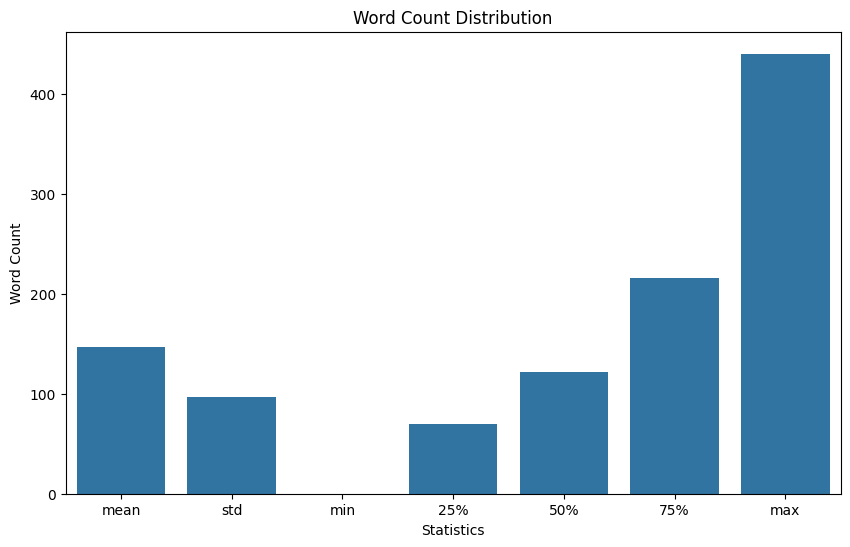

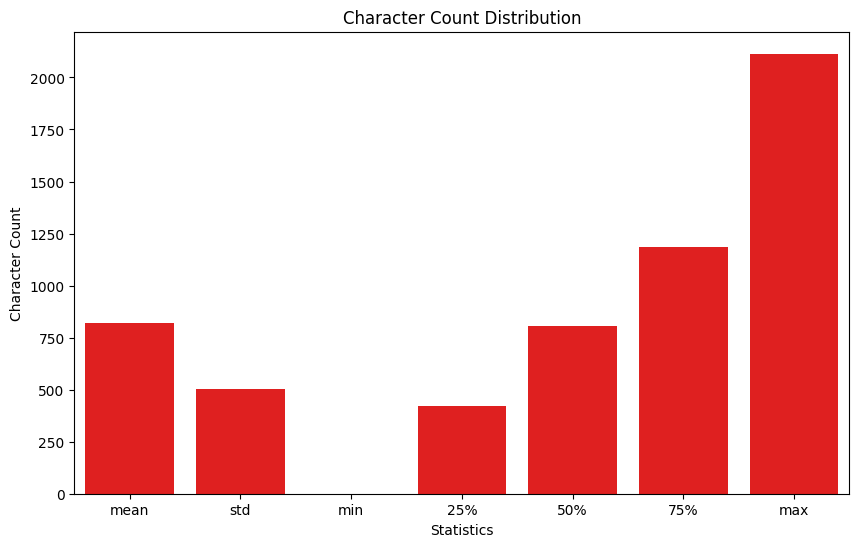

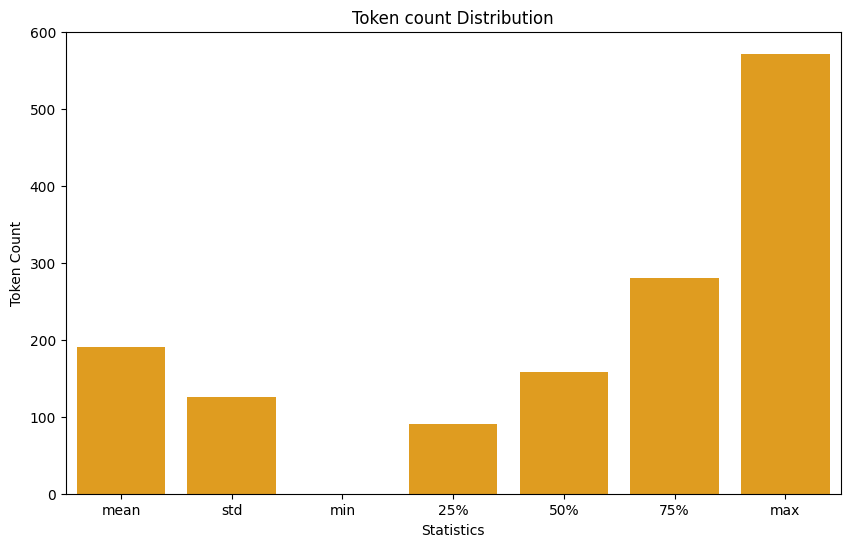

       Word_count  Token_count   Char_count
count  553.000000   553.000000   553.000000
mean   146.712477   190.726221   818.189873
std     96.323365   125.220375   503.449152
min      0.000000     0.000000     0.000000
25%     70.000000    91.000000   422.000000
50%    122.000000   158.600000   805.000000
75%    216.000000   280.800000  1184.000000
max    440.000000   572.000000  2114.000000


In [15]:
gen_ai.viusal_eda_before_chunk(docs)

# Make Chunks

In [16]:
chunks=gen_ai.Create_chunk()

        Word_count   Char_count  Token_count
count  2283.000000  2283.000000  2283.000000
mean     36.504161   238.883925    54.768287
std      10.692145    58.011718    18.450332
min       1.000000     9.000000     1.000000
25%      32.000000   231.000000    47.000000
50%      38.000000   252.000000    55.000000
75%      44.000000   277.000000    63.000000
max      65.000000   300.000000   176.000000


# Make the vector store and get the retriver object

In [17]:
vectorestore=gen_ai.CreateVectoreStroe(chunks=chunks)

✅Collection already exists. Loading existing collection.


# Make Retrivers


In [18]:
retriver=gen_ai.Get_retriver(vectorestore=vectorestore)

# Generate The response

In [19]:
response=gen_ai.Get_relevant_docs( retriver=retriver)

In [20]:
response

['Further Reading\nAny introductory statistics text will have illustrations of the t-statistic and its\nuses; two good ones are Statistics, 4th ed., by David Freedman, Robert\nPisani, and Roger Purves (W. W. Norton, 2007) and The Basic Practice of\nStatistics by David S. Moore (Palgrave Macmillan, 2010).',
 'Chapter 1. Exploratory Data Analysis\nAs a discipline, statistics has mostly developed in the past century. Probability\ntheory — the mathematical foundation for statistics — was developed in the 17th\nto 19th centuries based on work by Thomas Bayes, Pierre-Simon Laplace, and\nCarl Gauss. In contrast to the purely theoretical nature of probability, statistics is\nan applied science concerned with analysis and modeling of data. Modern\nstatistics as a rigorous scientific discipline traces its roots back to the late 1800s\nand Francis Galton and Karl Pearson. R. A. Fisher, in the early 20th century, was\na leading pioneer of modern statistics, introducing key ideas of experimental\nd